<a href="https://colab.research.google.com/github/juhee0528-lang/git/blob/main/lending_club_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 0. 라이브러리 불러오기
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report
)

from lightgbm import LGBMClassifier

In [2]:
# ============================================================
# 1. 데이터 불러오기
# ============================================================

train_path = "train.csv"
val_path = "validation.csv"

train = pd.read_csv(train_path)
val = pd.read_csv(val_path)

print("Train 크기:", train.shape)
print("Validation 크기:", val.shape)

print("\nTrain 컬럼 수:", len(train.columns))
print("Validation 컬럼 수:", len(val.columns))



Train 크기: (310778, 66)
Validation 크기: (268623, 66)

Train 컬럼 수: 66
Validation 컬럼 수: 66


In [3]:
# ============================================================
# 2. 주요 컬럼 설정 및 확인
# ============================================================

TARGET = "default"
INTEREST_COL = "int_rate"
TREASURY_COL = "treasury_yield"

required_columns = [
    TARGET,
    INTEREST_COL,
    TREASURY_COL
]

for col in required_columns:

    if col not in train.columns:
        raise ValueError(
            f"Train 데이터에 {col} 컬럼이 없습니다."
        )

    if col not in val.columns:
        raise ValueError(
            f"Validation 데이터에 {col} 컬럼이 없습니다."
        )


print("\n필수 컬럼 확인 완료")
print("종속변수:", TARGET)
print("대출 이자율:", INTEREST_COL)
print("국채 수익률:", TREASURY_COL)


필수 컬럼 확인 완료
종속변수: default
대출 이자율: int_rate
국채 수익률: treasury_yield


In [5]:
# ============================================================
# 3. inf와 -inf를 결측값으로 변환
# ============================================================

train = train.replace(
    [np.inf, -np.inf],
    np.nan
)

val = val.replace(
    [np.inf, -np.inf],
    np.nan
)

In [6]:
# ============================================================
# 4. 종속변수 결측값 처리
# ============================================================

# default가 없는 행은 모델 학습과 평가에 사용할 수 없으므로 제거
train = train.dropna(
    subset=[TARGET]
).copy()

val = val.dropna(
    subset=[TARGET]
).copy()


# default를 숫자형으로 변환
train[TARGET] = pd.to_numeric(
    train[TARGET],
    errors="coerce"
)

val[TARGET] = pd.to_numeric(
    val[TARGET],
    errors="coerce"
)

# 숫자형 변환 과정에서 다시 결측값이 된 행 제거
train = train.dropna(
    subset=[TARGET]
).copy()

val = val.dropna(
    subset=[TARGET]
).copy()


# 0과 1인 행만 사용
train = train[
    train[TARGET].isin([0, 1])
].copy()

val = val[
    val[TARGET].isin([0, 1])
].copy()


train[TARGET] = train[TARGET].astype(int)
val[TARGET] = val[TARGET].astype(int)


print("\n종속변수 결측값 처리 완료")
print("Train 크기:", train.shape)
print("Validation 크기:", val.shape)


종속변수 결측값 처리 완료
Train 크기: (310778, 66)
Validation 크기: (268623, 66)


In [7]:
# ============================================================
# 5. bool 컬럼을 0과 1로 변환
# ============================================================

train_bool_cols = train.select_dtypes(
    include=["bool"]
).columns.tolist()

val_bool_cols = val.select_dtypes(
    include=["bool"]
).columns.tolist()


for col in train_bool_cols:
    train[col] = train[col].astype("int8")

for col in val_bool_cols:
    val[col] = val[col].astype("int8")


print("\nbool 컬럼 변환 완료")
print("Train bool 컬럼 수:", len(train_bool_cols))
print("Validation bool 컬럼 수:", len(val_bool_cols))


bool 컬럼 변환 완료
Train bool 컬럼 수: 11
Validation bool 컬럼 수: 11


In [8]:
# ============================================================
# 6. 독립변수와 종속변수 분리
# ============================================================

X_train = train.drop(
    columns=[TARGET]
).copy()

y_train = train[TARGET].copy()


X_val = val.drop(
    columns=[TARGET]
).copy()

y_val = val[TARGET].copy()


# Validation 컬럼을 Train 컬럼과 동일하게 맞춤
# Train에는 있지만 Validation에는 없는 컬럼은 NaN으로 생성됨
# Validation에만 있는 컬럼은 제거됨
X_val = X_val.reindex(
    columns=X_train.columns
)


print("\nX_train 크기:", X_train.shape)
print("X_val 크기:", X_val.shape)

print("\ny_train 클래스 분포")
print(y_train.value_counts())

print("\ny_train 클래스 비율")
print(
    y_train.value_counts(
        normalize=True
    ).round(4)
)


X_train 크기: (310778, 65)
X_val 크기: (268623, 65)

y_train 클래스 분포
default
0    155389
1    155389
Name: count, dtype: int64

y_train 클래스 비율
default
0    0.5
1    0.5
Name: proportion, dtype: float64


In [9]:
# ============================================================
# 7. 전체 독립변수를 숫자형으로 변환
# ============================================================

for col in X_train.columns:

    X_train[col] = pd.to_numeric(
        X_train[col],
        errors="coerce"
    )

    X_val[col] = pd.to_numeric(
        X_val[col],
        errors="coerce"
    )


# 변환 이후 발생한 무한대 값 다시 처리
X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_val = X_val.replace(
    [np.inf, -np.inf],
    np.nan
)


train_non_numeric = X_train.select_dtypes(
    exclude=[np.number]
).columns.tolist()

val_non_numeric = X_val.select_dtypes(
    exclude=[np.number]
).columns.tolist()


print("\nTrain 비숫자형 컬럼:", train_non_numeric)
print("Validation 비숫자형 컬럼:", val_non_numeric)


Train 비숫자형 컬럼: []
Validation 비숫자형 컬럼: []


In [10]:
# ============================================================
# 8. 전처리와 LightGBM 파이프라인
# ============================================================

model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "classifier",
            LGBMClassifier(
                objective="binary",

                # 모델 학습
                n_estimators=500,
                learning_rate=0.03,
                num_leaves=31,
                max_depth=-1,

                # 과적합 방지
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=0.1,

                # 클래스 불균형 대응
                class_weight="balanced",

                random_state=42,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)

In [11]:
# ============================================================
# 9. 모델 학습
# ============================================================

model.fit(
    X_train,
    y_train
)

print("\n모델 학습 완료")



모델 학습 완료


In [12]:
# ============================================================
# 10. Validation 데이터의 부도확률 예측
# ============================================================

val_default_prob = model.predict_proba(
    X_val
)[:, 1]


val_result = val.copy()

val_result["pred_default_prob"] = (
    val_default_prob
)


print("\n부도확률 예측 결과")

print(
    val_result[
        [
            TARGET,
            INTEREST_COL,
            TREASURY_COL,
            "pred_default_prob"
        ]
    ].head()
)


부도확률 예측 결과
   default  int_rate  treasury_yield  pred_default_prob
0        1     11.49        0.897619           0.453833
1        1     13.99        1.280455           0.598015
2        0     15.61        1.026364           0.515609
3        0     14.65        1.030000           0.465047
4        0     11.48        1.140000           0.435035


In [13]:
# ============================================================
# 11. 기본 분류 성능 평가
# ============================================================

auc = roc_auc_score(
    y_val,
    val_default_prob
)


basic_pred = (
    val_default_prob >= 0.5
).astype(int)


accuracy = accuracy_score(
    y_val,
    basic_pred
)


print("\n" + "=" * 50)
print("기본 분류 성능")
print("=" * 50)

print(
    "Validation ROC-AUC:",
    round(auc, 4)
)

print(
    "Validation Accuracy:",
    round(accuracy, 4)
)

print("\n분류 리포트")

print(
    classification_report(
        y_val,
        basic_pred,
        digits=4,
        zero_division=0
    )
)


기본 분류 성능
Validation ROC-AUC: 0.7242
Validation Accuracy: 0.6513

분류 리포트
              precision    recall  f1-score   support

           0     0.8941    0.6443    0.7489    216826
           1     0.3137    0.6806    0.4294     51797

    accuracy                         0.6513    268623
   macro avg     0.6039    0.6624    0.5892    268623
weighted avg     0.7822    0.6513    0.6873    268623



In [14]:
# ============================================================
# 12. 이자율과 국채 수익률 생성
# ============================================================

# 원본 데이터가 11.49, 1.01과 같은 퍼센트 단위라고 가정
# 계산할 때 100으로 나누어 소수 단위로 변환

val_result["interest_return"] = (
    pd.to_numeric(
        val_result[INTEREST_COL],
        errors="coerce"
    ) / 100
)


val_result["treasury_return"] = (
    pd.to_numeric(
        val_result[TREASURY_COL],
        errors="coerce"
    ) / 100
)


# 비정상적인 값 처리
val_result[
    [
        "interest_return",
        "treasury_return"
    ]
] = val_result[
    [
        "interest_return",
        "treasury_return"
    ]
].replace(
    [np.inf, -np.inf],
    np.nan
)


print("\n수익률 관련 결측값")

print(
    val_result[
        [
            "interest_return",
            "treasury_return"
        ]
    ].isna().sum()
)


수익률 관련 결측값
interest_return    0
treasury_return    0
dtype: int64


In [15]:
# ============================================================
# 13. 실제 대출 수익률 계산
# ============================================================

# 부도가 발생했을 때 회수 가능한 원금 비율
# 0.0은 부도 발생 시 원금을 전혀 회수하지 못한다는 가정
RECOVERY_RATE = 0.0


val_result["realized_return"] = np.where(
    val_result[TARGET] == 0,

    # 정상 상환이면 대출 이자율만큼 수익
    val_result["interest_return"],

    # 부도이면 원금 손실
    -1 + RECOVERY_RATE
)


In [16]:
# ============================================================
# 14. 기대 대출 수익률 계산
# ============================================================

# 기대 대출 수익률
#
# 정상 상환 확률 × 정상 상환 수익률
# +
# 부도확률 × 부도 발생 시 수익률

val_result["expected_loan_return"] = (
    (
        1
        - val_result["pred_default_prob"]
    )
    * val_result["interest_return"]

    +

    val_result["pred_default_prob"]
    * (
        -1
        + RECOVERY_RATE
    )
)


In [17]:
# ============================================================
# 15. 기대 초과수익률 계산
# ============================================================

# 대출의 기대수익률에서 국채 수익률을 차감
#
# 값이 클수록 국채보다 높은 수익을 기대할 수 있는 대출

val_result["expected_excess_return"] = (
    val_result["expected_loan_return"]
    - val_result["treasury_return"]
)


# 실제 결과를 바탕으로 계산한 초과수익률
# Sharpe Ratio 평가에 사용

val_result["realized_excess_return"] = (
    val_result["realized_return"]
    - val_result["treasury_return"]
)


# 수익률 계산에 필요한 값이 없는 행 제거
portfolio_data = val_result.dropna(
    subset=[
        "pred_default_prob",
        "interest_return",
        "treasury_return",
        "expected_loan_return",
        "expected_excess_return",
        "realized_return",
        "realized_excess_return"
    ]
).copy()


print("\n포트폴리오 분석 가능 대출 수:", len(portfolio_data))


print("\n기대수익률 계산 결과")

print(
    portfolio_data[
        [
            TARGET,
            "pred_default_prob",
            "interest_return",
            "treasury_return",
            "expected_loan_return",
            "expected_excess_return",
            "realized_return",
            "realized_excess_return"
        ]
    ].head()
)



포트폴리오 분석 가능 대출 수: 268623

기대수익률 계산 결과
   default  pred_default_prob  interest_return  treasury_return  \
0        1           0.453833           0.1149         0.008976   
1        1           0.598015           0.1399         0.012805   
2        0           0.515609           0.1561         0.010264   
3        0           0.465047           0.1465         0.010300   
4        0           0.435035           0.1148         0.011400   

   expected_loan_return  expected_excess_return  realized_return  \
0             -0.391079               -0.400055          -1.0000   
1             -0.541777               -0.554582          -1.0000   
2             -0.439996               -0.450260           0.1561   
3             -0.386677               -0.396977           0.1465   
4             -0.370177               -0.381577           0.1148   

   realized_excess_return  
0               -1.008976  
1               -1.012805  
2                0.145836  
3                0.136200  
4        

In [18]:
# ============================================================
# 16. 기대 초과수익률 분포 확인
# ============================================================

print("\n기대 초과수익률 요약 통계")

print(
    portfolio_data[
        "expected_excess_return"
    ].describe()
)


기대 초과수익률 요약 통계
count    268623.000000
mean         -0.402424
std           0.198806
min          -0.935721
25%          -0.553031
50%          -0.395776
75%          -0.245336
max           0.027691
Name: expected_excess_return, dtype: float64


In [19]:
# ============================================================
# 17. 기대 초과수익률 Threshold 생성
# ============================================================

# 데이터의 실제 기대 초과수익률 범위를 이용
# 하위 1%에서 상위 99% 사이를 100개 기준값으로 탐색

threshold_min = portfolio_data[
    "expected_excess_return"
].quantile(0.01)

threshold_max = portfolio_data[
    "expected_excess_return"
].quantile(0.99)


expected_return_thresholds = np.linspace(
    threshold_min,
    threshold_max,
    100
)


print("\nThreshold 탐색 범위")
print(
    "최솟값:",
    round(threshold_min, 4)
)

print(
    "최댓값:",
    round(threshold_max, 4)
)



Threshold 탐색 범위
최솟값: -0.8175
최댓값: -0.0329


In [20]:
# ============================================================
# 18. Threshold별 Sharpe Ratio 계산 함수
# ============================================================

def calculate_sharpe_by_expected_return(
    data,
    thresholds,
    min_investments=100,
    ddof=1
):
    """
    기대 초과수익률 기준값별 포트폴리오 성과를 계산합니다.

    투자 대상:
        expected_excess_return이 threshold 이상인 대출

    Sharpe Ratio:
        선택된 대출의 실제 초과수익률 평균
        / 실제 초과수익률 표준편차

    Parameters
    ----------
    data : pandas.DataFrame
        포트폴리오 분석 데이터

    thresholds : array-like
        적용할 기대 초과수익률 기준값

    min_investments : int
        Sharpe Ratio를 계산하기 위한 최소 투자 건수

    ddof : int
        표준편차 계산의 자유도

    Returns
    -------
    pandas.DataFrame
        기준값별 포트폴리오 성과
    """

    results = []


    for threshold in thresholds:

        # 기대 초과수익률이 기준값 이상인 대출 선택
        selected = data[
            data["expected_excess_return"]
            >= threshold
        ].copy()


        investment_count = len(selected)


        # 투자 건수가 너무 적으면 Sharpe Ratio 계산 제외
        if investment_count < min_investments:

            results.append(
                {
                    "threshold": threshold,
                    "investment_count": investment_count,
                    "investment_ratio":
                        investment_count / len(data),

                    "default_rate": np.nan,

                    "mean_pred_default_prob": np.nan,

                    "mean_interest_return": np.nan,

                    "mean_expected_loan_return": np.nan,

                    "mean_expected_excess_return": np.nan,

                    "mean_realized_return": np.nan,

                    "mean_treasury_return": np.nan,

                    "mean_realized_excess_return": np.nan,

                    "realized_excess_return_std": np.nan,

                    "sharpe_ratio": np.nan
                }
            )

            continue


        mean_realized_excess_return = selected[
            "realized_excess_return"
        ].mean()


        realized_excess_return_std = selected[
            "realized_excess_return"
        ].std(
            ddof=ddof
        )


        # 표준편차가 0이거나 결측값이면 계산 불가능
        if (
            pd.isna(realized_excess_return_std)
            or realized_excess_return_std == 0
        ):
            sharpe_ratio = np.nan

        else:
            sharpe_ratio = (
                mean_realized_excess_return
                / realized_excess_return_std
            )


        results.append(
            {
                "threshold": threshold,

                "investment_count":
                    investment_count,

                "investment_ratio":
                    investment_count / len(data),

                "default_rate":
                    selected[TARGET].mean(),

                "mean_pred_default_prob":
                    selected[
                        "pred_default_prob"
                    ].mean(),

                "mean_interest_return":
                    selected[
                        "interest_return"
                    ].mean(),

                "mean_expected_loan_return":
                    selected[
                        "expected_loan_return"
                    ].mean(),

                "mean_expected_excess_return":
                    selected[
                        "expected_excess_return"
                    ].mean(),

                "mean_realized_return":
                    selected[
                        "realized_return"
                    ].mean(),

                "mean_treasury_return":
                    selected[
                        "treasury_return"
                    ].mean(),

                "mean_realized_excess_return":
                    mean_realized_excess_return,

                "realized_excess_return_std":
                    realized_excess_return_std,

                "sharpe_ratio":
                    sharpe_ratio
            }
        )


    return pd.DataFrame(results)

In [21]:
# ============================================================
# 19. Threshold별 포트폴리오 성과 계산
# ============================================================

sharpe_results = (
    calculate_sharpe_by_expected_return(
        data=portfolio_data,
        thresholds=expected_return_thresholds,
        min_investments=100,
        ddof=1
    )
)


print("\nThreshold별 결과 일부")

print(
    sharpe_results.head(10)
)


Threshold별 결과 일부
   threshold  investment_count  investment_ratio  default_rate  \
0  -0.817485            265936          0.989997      0.188214   
1  -0.809560            265344          0.987793      0.187312   
2  -0.801634            264610          0.985061      0.186282   
3  -0.793709            263784          0.981986      0.185079   
4  -0.785784            262855          0.978528      0.183888   
5  -0.777859            261789          0.974559      0.182552   
6  -0.769934            260684          0.970446      0.181135   
7  -0.762008            259478          0.965956      0.179776   
8  -0.754083            258167          0.961076      0.178280   
9  -0.746158            256715          0.955670      0.176659   

   mean_pred_default_prob  mean_interest_return  mean_expected_loan_return  \
0                0.449266              0.130301                  -0.384656   
1                0.448414              0.130101                  -0.383741   
2                0.44

In [22]:
# ============================================================
# 20. Sharpe Ratio가 가장 높은 Threshold 찾기
# ============================================================

valid_results = sharpe_results.dropna(
    subset=["sharpe_ratio"]
).copy()


if valid_results.empty:

    raise ValueError(
        "Sharpe Ratio를 계산할 수 있는 "
        "기대 초과수익률 기준값이 없습니다. "
        "min_investments를 줄이거나 데이터를 확인하세요."
    )
best_index = valid_results[
    "sharpe_ratio"
].idxmax()


best_result = valid_results.loc[
    best_index
]


best_threshold = best_result[
    "threshold"
]


print("\n" + "=" * 60)
print("최적 기대 초과수익률 투자 기준")
print("=" * 60)

print(
    "Best Threshold:",
    f"{best_threshold * 100:.2f}%"
)

print(
    "Best Sharpe Ratio:",
    round(
        best_result["sharpe_ratio"],
        4
    )
)

print(
    "투자 건수:",
    f"{int(best_result['investment_count']):,}건"
)

print(
    "전체 대출 중 투자 비율:",
    f"{best_result['investment_ratio'] * 100:.2f}%"
)

print(
    "선택된 대출의 실제 부도율:",
    f"{best_result['default_rate'] * 100:.2f}%"
)

print(
    "평균 예측 부도확률:",
    f"{best_result['mean_pred_default_prob'] * 100:.2f}%"
)

print(
    "평균 대출 이자율:",
    f"{best_result['mean_interest_return'] * 100:.2f}%"
)

print(
    "평균 기대 대출 수익률:",
    f"{best_result['mean_expected_loan_return'] * 100:.2f}%"
)

print(
    "평균 기대 초과수익률:",
    f"{best_result['mean_expected_excess_return'] * 100:.2f}%"
)

print(
    "평균 실제 대출 수익률:",
    f"{best_result['mean_realized_return'] * 100:.2f}%"
)

print(
    "평균 국채 수익률:",
    f"{best_result['mean_treasury_return'] * 100:.2f}%"
)

print(
    "평균 실제 초과수익률:",
    f"{best_result['mean_realized_excess_return'] * 100:.2f}%"
)

print(
    "실제 초과수익률 표준편차:",
    f"{best_result['realized_excess_return_std'] * 100:.2f}%"
)


최적 기대 초과수익률 투자 기준
Best Threshold: -3.29%
Best Sharpe Ratio: 0.2849
투자 건수: 2,687건
전체 대출 중 투자 비율: 1.00%
선택된 대출의 실제 부도율: 1.38%
평균 예측 부도확률: 6.50%
평균 대출 이자율: 6.03%
평균 기대 대출 수익률: -0.86%
평균 기대 초과수익률: -1.91%
평균 실제 대출 수익률: 4.57%
평균 국채 수익률: 1.04%
평균 실제 초과수익률: 3.53%
실제 초과수익률 표준편차: 12.39%


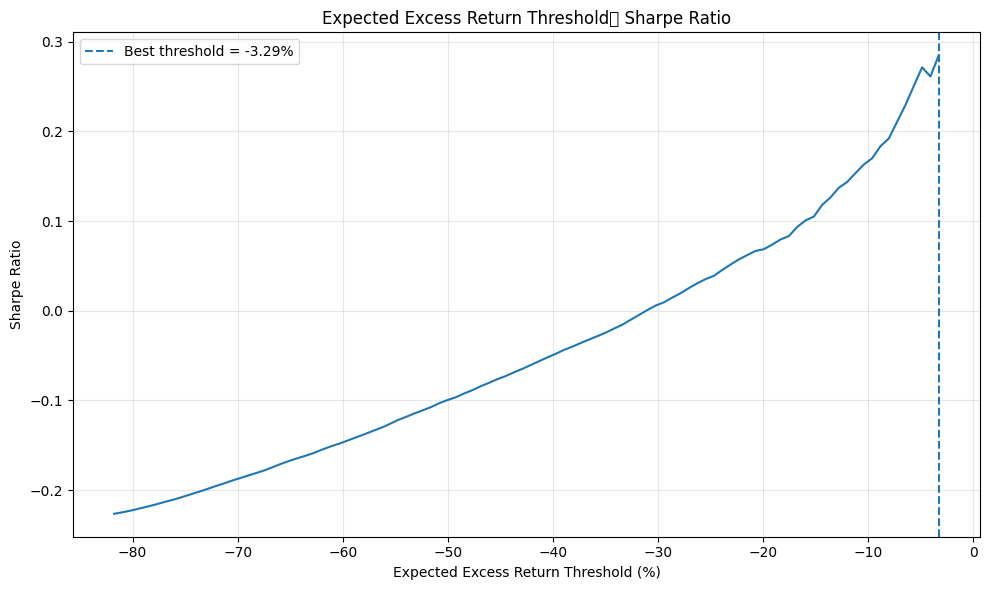

In [23]:
# ============================================================
# 21. 기대 초과수익률 Threshold와 Sharpe Ratio 그래프
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    sharpe_results["threshold"] * 100,
    sharpe_results["sharpe_ratio"]
)

plt.axvline(
    x=best_threshold * 100,
    linestyle="--",
    label=(
        f"Best threshold = "
        f"{best_threshold * 100:.2f}%"
    )
)

plt.xlabel(
    "Expected Excess Return Threshold (%)"
)

plt.ylabel(
    "Sharpe Ratio"
)

plt.title(
    "Expected Excess Return Threshold별 Sharpe Ratio"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

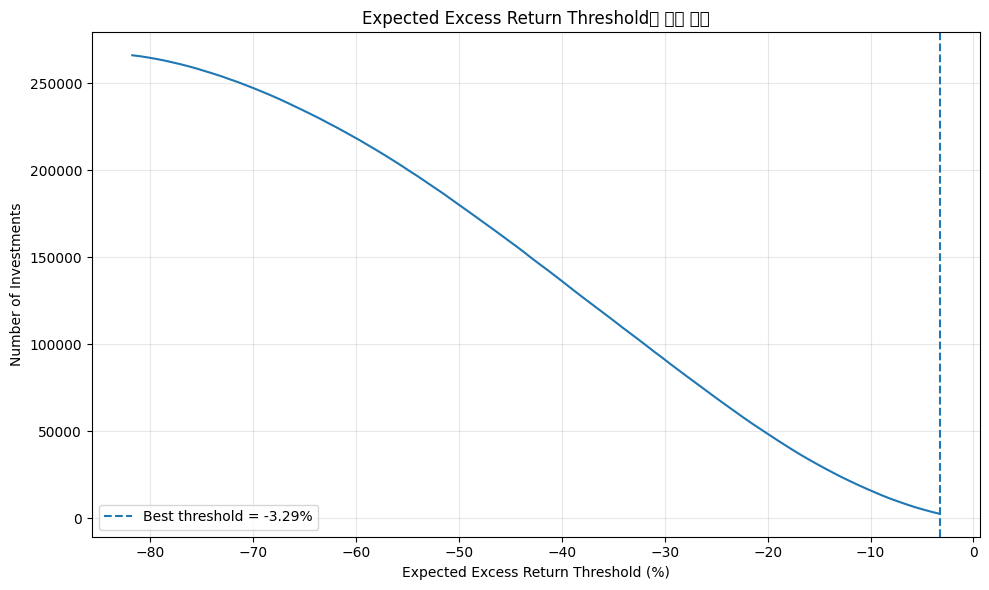

In [24]:
# ============================================================
# 22. Threshold와 투자 건수 그래프
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    sharpe_results["threshold"] * 100,
    sharpe_results["investment_count"]
)

plt.axvline(
    x=best_threshold * 100,
    linestyle="--",
    label=(
        f"Best threshold = "
        f"{best_threshold * 100:.2f}%"
    )
)

plt.xlabel(
    "Expected Excess Return Threshold (%)"
)

plt.ylabel(
    "Number of Investments"
)

plt.title(
    "Expected Excess Return Threshold별 투자 건수"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

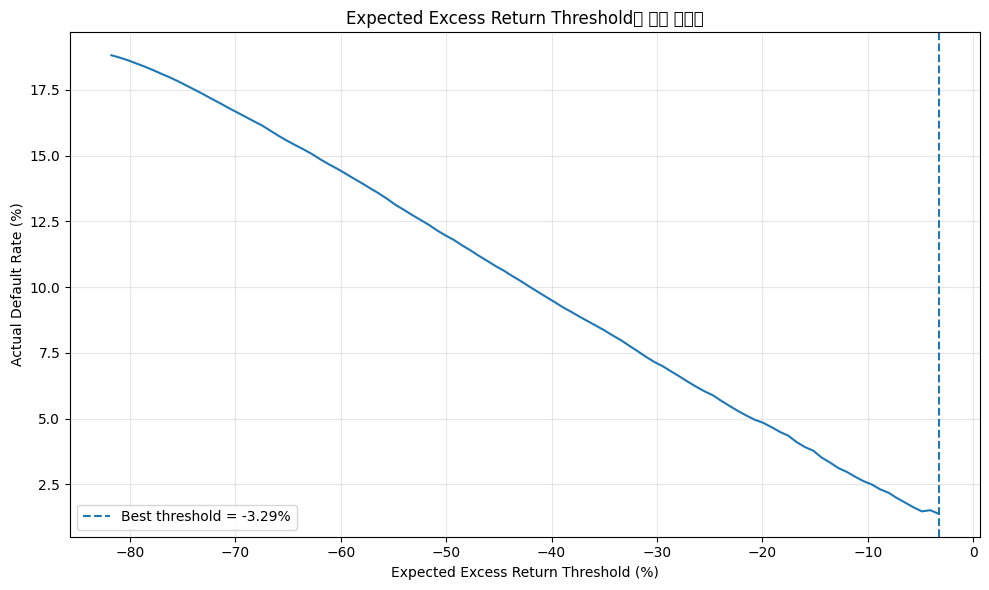

In [25]:
# ============================================================
# 23. Threshold와 실제 부도율 그래프
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    sharpe_results["threshold"] * 100,
    sharpe_results["default_rate"] * 100
)

plt.axvline(
    x=best_threshold * 100,
    linestyle="--",
    label=(
        f"Best threshold = "
        f"{best_threshold * 100:.2f}%"
    )
)

plt.xlabel(
    "Expected Excess Return Threshold (%)"
)

plt.ylabel(
    "Actual Default Rate (%)"
)

plt.title(
    "Expected Excess Return Threshold별 실제 부도율"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# 24. Sharpe Ratio 상위 10개 결과
# ============================================================

top_10_results = (
    valid_results
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
    .copy()
)


top_10_display = top_10_results[
    [
        "threshold",
        "sharpe_ratio",
        "investment_count",
        "investment_ratio",
        "default_rate",
        "mean_pred_default_prob",
        "mean_interest_return",
        "mean_expected_loan_return",
        "mean_expected_excess_return",
        "mean_realized_return",
        "mean_treasury_return",
        "mean_realized_excess_return",
        "realized_excess_return_std"
    ]
].copy()


percent_columns = [
    "threshold",
    "investment_ratio",
    "default_rate",
    "mean_pred_default_prob",
    "mean_interest_return",
    "mean_expected_loan_return",
    "mean_expected_excess_return",
    "mean_realized_return",
    "mean_treasury_return",
    "mean_realized_excess_return",
    "realized_excess_return_std"
]


for col in percent_columns:

    top_10_display[col] = (
        top_10_display[col]
        * 100
    ).round(2)


top_10_display[
    "sharpe_ratio"
] = top_10_display[
    "sharpe_ratio"
].round(4)


print("\nSharpe Ratio 상위 10개 결과")

display(
    top_10_display
)


Sharpe Ratio 상위 10개 결과


,threshold,sharpe_ratio,investment_count,investment_ratio,default_rate,mean_pred_default_prob,mean_interest_return,mean_expected_loan_return,mean_expected_excess_return,mean_realized_return,mean_treasury_return,mean_realized_excess_return,realized_excess_return_std
99,-3.29,0.2849,2687,1.00,1.38,6.50,6.03,-0.86,-1.91,4.57,1.04,3.53,12.39
97,-4.87,0.2714,5107,1.90,1.47,7.52,6.13,-1.85,-2.95,4.57,1.10,3.48,12.80
98,-4.08,0.2613,3832,1.43,1.51,7.01,6.08,-1.36,-2.44,4.47,1.07,3.39,12.99
96,-5.67,0.2506,6477,2.41,1.62,8.03,6.20,-2.33,-3.44,4.48,1.11,3.37,13.46
95,-6.46,0.2294,7993,2.98,1.80,8.56,6.28,-2.83,-3.94,4.37,1.11,3.25,14.18
94,-7.25,0.2108,9614,3.58,1.98,9.07,6.36,-3.31,-4.43,4.25,1.12,3.13,14.85
93,-8.04,0.1921,11290,4.20,2.18,9.59,6.44,-3.78,-4.91,4.12,1.13,3.00,15.59
92,-8.84,0.1835,13132,4.89,2.31,10.13,6.54,-4.28,-5.41,4.08,1.13,2.95,16.05
91,-9.63,0.1700,15120,5.63,2.49,10.68,6.64,-4.78,-5.91,3.97,1.13,2.84,16.69
90,-10.42,0.1631,17138,6.38,2.62,11.20,6.73,-5.26,-6.39,3.93,1.14,2.79,17.11


In [27]:
# ============================================================
# 25. 최적 투자 포트폴리오 추출
# ============================================================

best_portfolio = portfolio_data[
    portfolio_data["expected_excess_return"]
    >= best_threshold
].copy()


best_portfolio = best_portfolio.sort_values(
    "expected_excess_return",
    ascending=False
)


print("\n" + "=" * 60)
print("최적 포트폴리오 최종 결과")
print("=" * 60)

print(
    "최적 포트폴리오 대출 수:",
    f"{len(best_portfolio):,}건"
)

print(
    "최적 포트폴리오 투자 비율:",
    f"{len(best_portfolio) / len(portfolio_data) * 100:.2f}%"
)

print(
    "최적 포트폴리오 실제 부도율:",
    f"{best_portfolio[TARGET].mean() * 100:.2f}%"
)

print(
    "최적 포트폴리오 평균 예측 부도확률:",
    f"{best_portfolio['pred_default_prob'].mean() * 100:.2f}%"
)

print(
    "최적 포트폴리오 평균 대출 이자율:",
    f"{best_portfolio['interest_return'].mean() * 100:.2f}%"
)

print(
    "최적 포트폴리오 평균 기대 대출 수익률:",
    f"{best_portfolio['expected_loan_return'].mean() * 100:.2f}%"
)

print(
    "최적 포트폴리오 평균 기대 초과수익률:",
    f"{best_portfolio['expected_excess_return'].mean() * 100:.2f}%"
)

print(
    "최적 포트폴리오 평균 실제 수익률:",
    f"{best_portfolio['realized_return'].mean() * 100:.2f}%"
)

print(
    "최적 포트폴리오 평균 실제 초과수익률:",
    f"{best_portfolio['realized_excess_return'].mean() * 100:.2f}%"
)


best_portfolio_sharpe = (
    best_portfolio[
        "realized_excess_return"
    ].mean()

    /

    best_portfolio[
        "realized_excess_return"
    ].std(ddof=1)
)


print(
    "최적 포트폴리오 Sharpe Ratio:",
    round(
        best_portfolio_sharpe,
        4
    )
)


최적 포트폴리오 최종 결과
최적 포트폴리오 대출 수: 2,687건
최적 포트폴리오 투자 비율: 1.00%
최적 포트폴리오 실제 부도율: 1.38%
최적 포트폴리오 평균 예측 부도확률: 6.50%
최적 포트폴리오 평균 대출 이자율: 6.03%
최적 포트폴리오 평균 기대 대출 수익률: -0.86%
최적 포트폴리오 평균 기대 초과수익률: -1.91%
최적 포트폴리오 평균 실제 수익률: 4.57%
최적 포트폴리오 평균 실제 초과수익률: 3.53%
최적 포트폴리오 Sharpe Ratio: 0.2849


In [28]:
# ============================================================
# 26. 최적 투자 대출 일부 확인
# ============================================================

display_columns = [
    TARGET,
    INTEREST_COL,
    TREASURY_COL,
    "pred_default_prob",
    "interest_return",
    "treasury_return",
    "expected_loan_return",
    "expected_excess_return",
    "realized_return",
    "realized_excess_return"
]


# 데이터에 대출 ID가 존재하면 가장 앞에 표시
id_candidates = [
    "id",
    "loan_id",
    "member_id"
]

for id_col in id_candidates:

    if id_col in best_portfolio.columns:

        display_columns.insert(
            0,
            id_col
        )

        break


display(
    best_portfolio[
        display_columns
    ].head(20)
)

,default,int_rate,treasury_yield,pred_default_prob,interest_return,treasury_return,expected_loan_return,expected_excess_return,realized_return,realized_excess_return
123022,0,6.03,0.395909,0.027021,0.0603,0.003959,0.031650,0.027691,0.0603,0.056341
261849,0,6.62,0.816667,0.033985,0.0662,0.008167,0.029965,0.021798,0.0662,0.058033
104354,0,6.03,0.340455,0.034757,0.0603,0.003405,0.023447,0.020042,0.0603,0.056895
175961,0,6.62,0.398421,0.040703,0.0662,0.003984,0.022802,0.018818,0.0662,0.062216
224688,0,6.03,0.577000,0.034406,0.0603,0.005770,0.023820,0.018050,0.0603,0.054530
231844,0,8.46,0.218000,0.060021,0.0846,0.002180,0.019501,0.017321,0.0846,0.082420
9419,0,7.69,0.973636,0.047100,0.0769,0.009736,0.026178,0.016442,0.0769,0.067164
213706,0,6.03,0.688421,0.035222,0.0603,0.006884,0.022954,0.016070,0.0603,0.053416
263495,0,6.03,0.826190,0.034657,0.0603,0.008262,0.023553,0.015291,0.0603,0.052038
39894,0,6.03,0.685238,0.036091,0.0603,0.006852,0.022033,0.015181,0.0603,0.053448
